# Phase 8 - Learning to fly maneuvers with reinforcement learning

Everything so far builds up to this: agents that learn to fly from trial and error. The phase
follows a **curriculum** of increasingly difficult tasks:

| Step | Task | What the agent must learn |
|---|---|---|
| 8.1 | recover from an unusual attitude | basic stabilization |
| 8.2 | reach a heading, altitude and speed | navigation, avoiding overshoot |
| 8.3 | maximum *sustained* turn | energy management |
| 8.4 | fly through 3D waypoints | planning several maneuvers ahead |
| 8.5 | aerobatics: loop, roll, Immelmann, Split-S | long coordinated sequences |
| 8.6 | all of the above with **direct control-surface commands** | the hard, final version |

Steps 8.1–8.5 use the hierarchical action space (load factor, roll rate, throttle through the
fly-by-wire), first on the fast 3-DOF model, then transferred to the 6-DOF. This notebook
explains the algorithm, **trains an agent live**, shows an imitation-learning demo, and reviews
the results, including what went wrong.

Code: `src/jetfighter_rl/training/` : (`train.py`, `imitation.py`, `transfer.py`, `evaluate.py`),
experiment configs in `configs/training/*.yaml`.

In [1]:
%matplotlib inline
import json
import math
import tempfile
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from jetsim.viz.style import INK, INK_2, SERIES, apply_style
from stable_baselines3 import PPO

from jetfighter_rl.envs.baselines import evaluate, reference_policy
from jetfighter_rl.envs.jet_env import EnvConfig, JetEnv
from jetfighter_rl.training.callbacks import EVAL_SEED, AgentPolicy
from jetfighter_rl.training.config import DEFAULT_HYPERPARAMS, TrainConfig
from jetfighter_rl.training.evaluate import env_config_for, fly
from jetfighter_rl.training.imitation import behavior_cloning, collect_demonstrations
from jetfighter_rl.training.train import load_model, train_one

apply_style()
plt.rcParams["figure.dpi"] = 110
torch.set_num_threads(1)
DEG = math.pi / 180
ROOT = Path.cwd().parent
RUNS = ROOT / "results" / "runs"
HAVE_RUNS = RUNS.exists() and any(RUNS.glob("8_*/*/summary.json"))
print(
    f"recorded training runs found in results/runs/ ({len(list(RUNS.glob('8_*/*/summary.json')))})"
    if HAVE_RUNS
    else "no results/runs/ directory: the sections using recorded runs will be skipped"
)


def read_csv(path):
    """Evaluation history (CSV written during training) as a numpy structured array."""
    return np.genfromtxt(path, delimiter=",", names=True)


def fmt(ev):
    return (
        f"return {ev.mean_return:6.1f} ± {ev.std_return:4.1f} | success {ev.success_rate:4.0%}"
        f" | crash {ev.crash_rate:4.0%}"
    )

recorded training runs found in results/runs/ (36)


## 1. The algorithm: PPO

The agents are trained with **Proximal Policy Optimization** (Schulman et al., 2017), via
[Stable-Baselines3](https://stable-baselines3.readthedocs.io). PPO is an *actor-critic* method:

* the **actor** $\pi_\theta(a \mid o)$ is a Gaussian policy whose mean is a small neural network
  (2 hidden layers of 128 units);
* the **critic** $V_\phi(o)$ estimates the expected return from an observation.

The agent collects a batch of experience, estimates for each step how much better the action was
than expected : the **advantage**, computed with Generalized Advantage Estimation:

$$\delta_t = r_t + \gamma V_\phi(o_{t+1}) - V_\phi(o_t), \qquad
  \hat A_t = \sum_{l \ge 0} (\gamma\lambda)^l\, \delta_{t+l}$$

 then makes the good actions more likely, but **not too much at once**. That is PPO's key idea,
the clipped objective, with $\rho_t = \pi_\theta(a_t \mid o_t) / \pi_{\theta_{old}}(a_t \mid o_t)$:

$$L^{CLIP}(\theta) = \mathbb E_t\left[\min\big(\rho_t \hat A_t,\
  \operatorname{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\,\hat A_t\big)\right], \qquad \epsilon = 0.2$$

PPO is robust and forgiving of hyperparameters, a good default for continuous control. SAC (more
sample-efficient, off-policy) is also available in the code as a comparison.

### Project-specific settings (each one learned the hard way)

In [2]:
for key, value in DEFAULT_HYPERPARAMS["ppo"].items():
    print(f"  {key:<14} {value}")

  n_steps        1024
  batch_size     512
  n_epochs       10
  learning_rate  0.0003
  gamma          0.99
  gae_lambda     0.95
  clip_range     0.2
  ent_coef       0.0
  policy_kwargs  {'net_arch': [128, 128], 'log_std_init': -1.0}


* `log_std_init = -1` → initial exploration noise σ ≈ 0.37 instead of 1: fully random commands
  crash the aircraft within seconds, and the first episodes then teach nothing;
* rewards are normalized by a running estimate of the return's standard deviation
  (`VecNormalize`): without it the critic could not fit returns of order −100
  (explained variance ≈ 0);
* PyTorch runs on 1 thread: the networks are tiny, and extra threads fought the 8 simulator
  processes for CPU (throughput ÷6).

## 2. Training an agent live: step 8.1

Task: from a random unusual attitude (bank up to ±80°, climb/dive up to ±25°, rolling at up to
60°/s), return to wings-level flight within 10 s. The config file is
`configs/training/8_1_level.yaml` (200,000 steps, 8 parallel environments). The run below takes
about a minute or two on a laptop; it is evaluated every 20,000 steps on 10 fixed episodes,
alongside the autopilot on the same episodes.

In [3]:
cfg = TrainConfig.from_yaml(ROOT / "configs/training/8_1_level.yaml").override(seeds=[0])
out = Path(tempfile.mkdtemp()) / "8_1_level_live"
result = train_one(cfg, seed=0, out_dir=out, verbose=0)
history = read_csv(out / "evaluations.csv")
print(f"trained {result.timesteps:,} steps in {result.duration:.0f} s")
print(f"  autopilot : {fmt(result.baseline)}")
print(f"  best agent: {fmt(result.best)}")

trained 200,704 steps in 57 s
  autopilot : return   17.8 ±  5.8 | success 100% | crash   0%
  best agent: return   18.5 ±  3.9 | success 100% | crash   0%


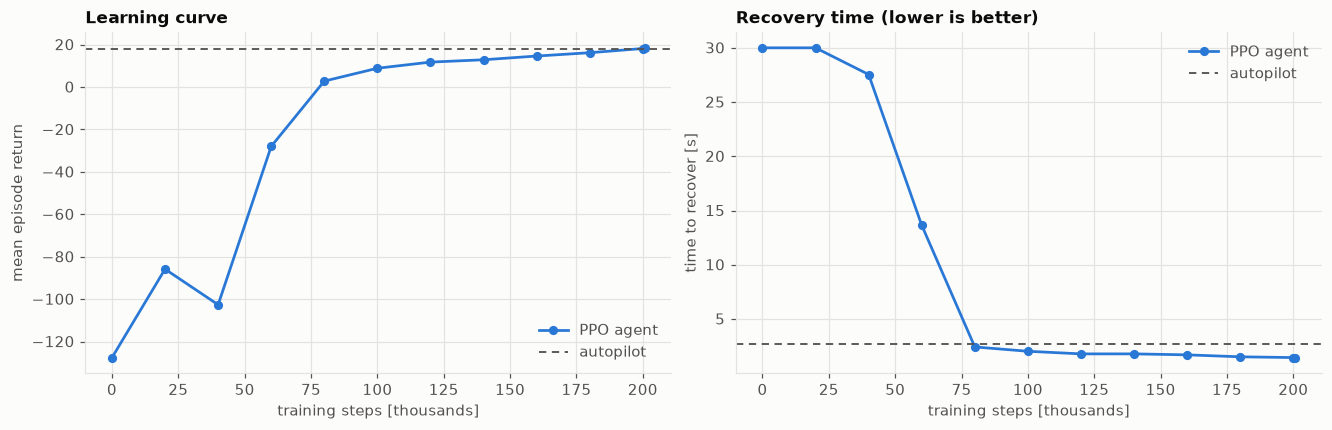

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
axes[0].plot(
    history["timesteps"] / 1000,
    history["mean_return"],
    "o-",
    color=SERIES[0],
    markersize=5,
    label="PPO agent",
)
axes[0].axhline(
    result.baseline.mean_return,
    color=INK_2,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    label="autopilot",
)
axes[0].set_ylabel("mean episode return"), axes[0].set_title("Learning curve")
axes[0].legend(loc="lower right")
axes[1].plot(
    history["timesteps"] / 1000,
    history["metric_recovery_time"],
    "o-",
    color=SERIES[0],
    markersize=5,
    label="PPO agent",
)
axes[1].axhline(
    result.baseline.metrics["recovery_time"],
    color=INK_2,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    label="autopilot",
)
axes[1].set_ylabel("time to recover [s]"), axes[1].set_title("Recovery time (lower is better)")
axes[1].legend(loc="upper right")
for ax in axes:
    ax.set_xlabel("training steps [thousands]")
plt.show()

Starting from a random network (whose return is far below zero), the agent reaches 100 %
success within a few tens of thousands of steps, a few minutes of simulated flight, and ends
up recovering **faster than the autopilot**. How? Let's watch both on the same episode.

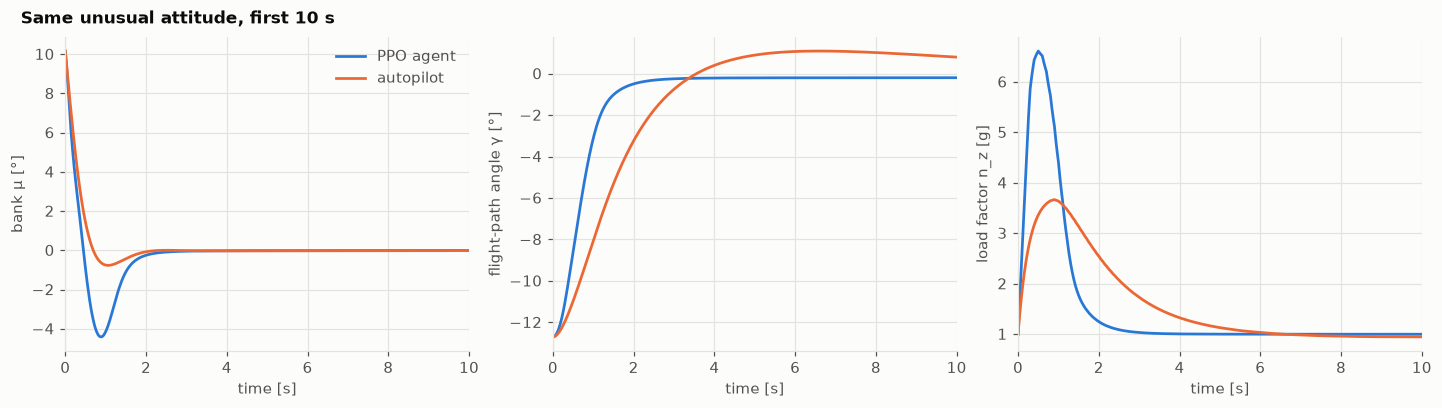

In [6]:
agent = AgentPolicy(PPO.load(out / "best_model.zip", device="cpu"))
env_cfg = cfg.env_config()
seed = EVAL_SEED + 3
rec_agent, _ = fly(env_cfg, agent, seed)
rec_ap, _ = fly(env_cfg, None, seed)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained", sharex=True)
for (name, rec), color in zip(
    (("PPO agent", rec_agent), ("autopilot", rec_ap)), SERIES, strict=False
):
    ins = rec.instruments
    axes[0].plot(rec.t, np.degrees(ins["bank"]), color=color, label=name)
    axes[1].plot(rec.t, np.degrees(ins["gamma"]), color=color, label=name)
    axes[2].plot(rec.t, ins["nz"], color=color, label=name)
axes[0].set_ylabel("bank μ [°]"), axes[1].set_ylabel("flight-path angle γ [°]")
axes[2].set_ylabel("load factor n_z [g]")
for ax in axes:
    ax.set_xlabel("time [s]")
    ax.set_xlim(0, 10)
axes[0].legend(loc="upper right")
fig.suptitle("Same unusual attitude, first 10 s", color=INK, fontweight="bold", x=0.01, ha="left")
plt.show()

The agent rolls wings-level and pulls much harder (several g) to kill the dive quickly, while
the autopilot, tuned for comfort, limits itself to gentle corrections. Nobody told the agent to
do this: it discovered that aggressive, but still smooth, inputs maximize the reward.

## 3. The full curriculum (recorded runs)

Longer tasks need millions of steps (15–40 min per task on 8 cores), so the notebook reads the
recorded runs instead of retraining. Each curve is the evaluation return during training, with
the autopilot's return on the same episodes as a dashed line.

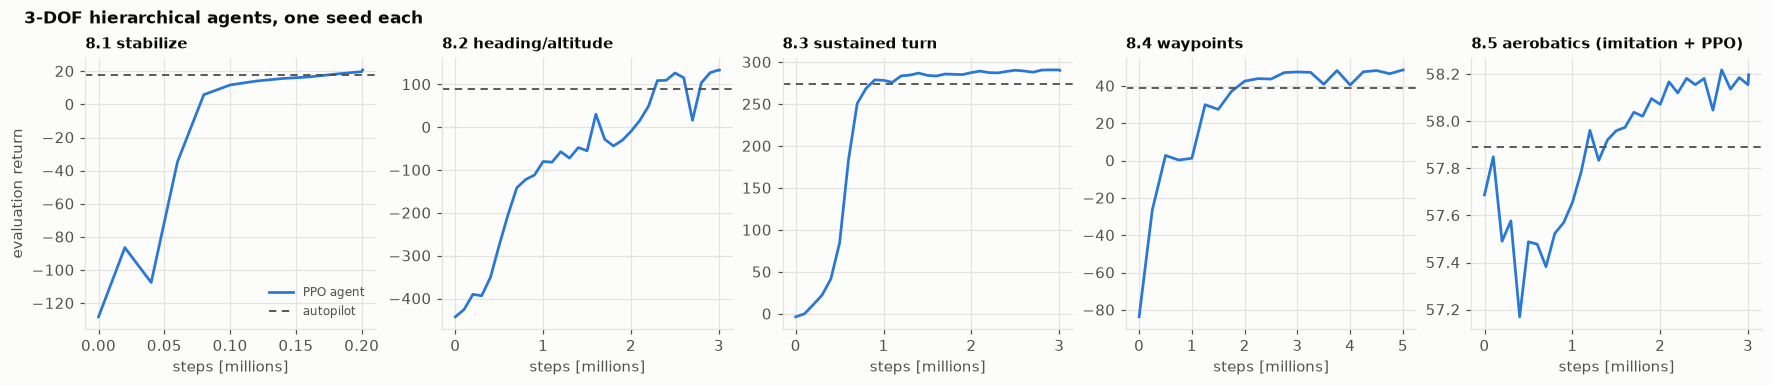

In [7]:
def load_run(name, pick="best"):
    """Latest run of an experiment, or the one with the best evaluated return."""
    summaries = sorted((RUNS / name).glob("*/summary.json"))
    if not summaries:
        return None
    data = [json.loads(p.read_text(encoding="utf-8")) for p in summaries]
    chosen = (
        max(data, key=lambda d: d["seeds"][0]["best"]["mean_return"])
        if pick == "best"
        else data[-1]
    )
    seed_dir = ROOT / chosen["seeds"][0]["directory"]
    return chosen, read_csv(seed_dir / "evaluations.csv"), seed_dir


CURRICULUM = [
    ("8_1_level", "8.1 stabilize"),
    ("8_2_heading_altitude", "8.2 heading/altitude"),
    ("8_3_sustained_turn", "8.3 sustained turn"),
    ("8_4_waypoints", "8.4 waypoints"),
    ("8_5_aerobatics_imitation", "8.5 aerobatics (imitation + PPO)"),
]
if HAVE_RUNS:
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.4), layout="constrained")
    for ax, (name, title) in zip(axes, CURRICULUM, strict=True):
        run = load_run(name)
        if run is None:
            ax.set_visible(False)
            continue
        summary, hist, _ = run
        ax.plot(hist["timesteps"] / 1e6, hist["mean_return"], color=SERIES[0], label="PPO agent")
        ax.axhline(
            summary["baseline"]["mean_return"],
            color=INK_2,
            linewidth=1.2,
            linestyle=(0, (4, 3)),
            label="autopilot",
        )
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("steps [millions]")
    axes[0].set_ylabel("evaluation return")
    axes[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(
        "3-DOF hierarchical agents, one seed each", color=INK, fontweight="bold", x=0.01, ha="left"
    )
    plt.show()

Every task ends at or above the autopilot. The aerobatics curve starts high because that agent
is first trained by **imitation** (section 5); pure RL could not discover the figures.

### Watching a trained agent: 3D waypoints (8.4)

Four waypoints, 5–9 km apart with turns up to 90° and altitude changes up to ±800 m. The agent
(blue) and the autopilot (orange) fly the same scenario:

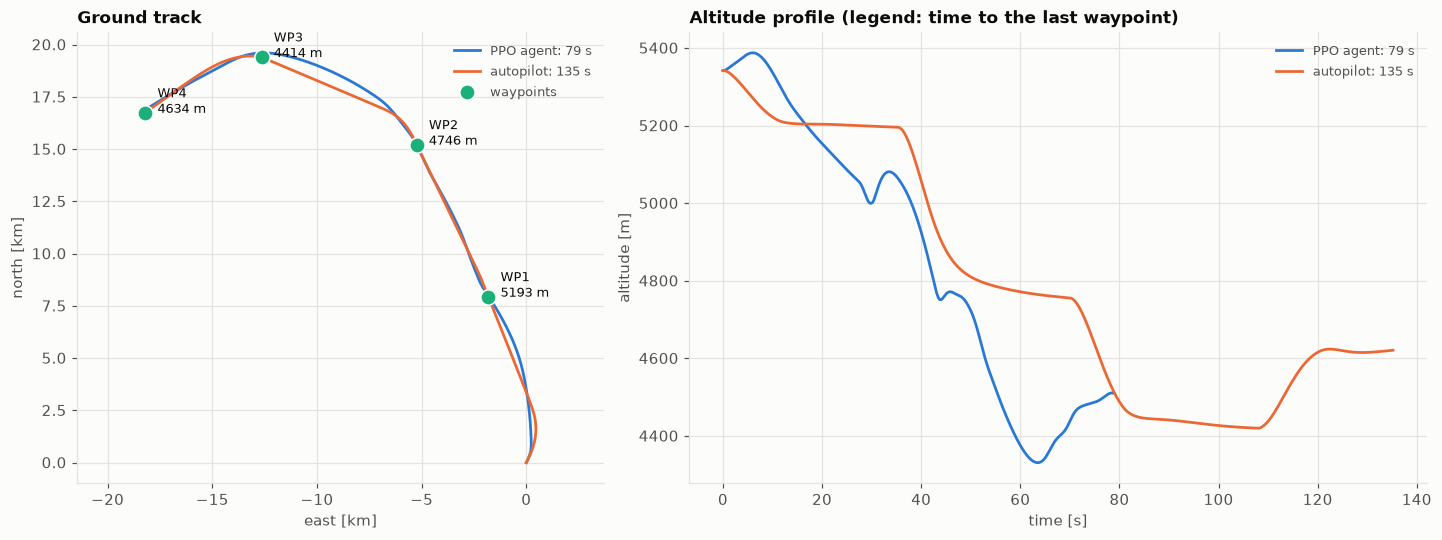

In [8]:
if HAVE_RUNS and (run := load_run("8_4_waypoints")) is not None:
    _, _, seed_dir = run
    model_path = seed_dir / "best_model.zip"
    wp_cfg = env_config_for(model_path)
    wp_agent = AgentPolicy(load_model(model_path))
    (rec_a, info_a), (rec_r, info_r) = (
        fly(wp_cfg, wp_agent, EVAL_SEED),
        fly(wp_cfg, None, EVAL_SEED),
    )
    wps = np.array(info_a["waypoints"])

    fig, axes = plt.subplots(
        1, 2, figsize=(13, 4.8), layout="constrained", gridspec_kw={"width_ratios": [1, 1.4]}
    )
    for (name, rec, info), color in zip(
        (("PPO agent", rec_a, info_a), ("autopilot", rec_r, info_r)), SERIES, strict=False
    ):
        ins = rec.instruments
        t_done = info["metrics"]["completion_time"]
        label = f"{name}: {t_done:.0f} s"
        axes[0].plot(ins["east"] / 1000, ins["north"] / 1000, color=color, label=label)
        axes[1].plot(rec.t, ins["altitude"], color=color, label=label)
    axes[0].plot(
        wps[:, 1] / 1000,
        wps[:, 0] / 1000,
        "o",
        color=SERIES[2],
        markersize=10,
        markeredgecolor="white",
        label="waypoints",
    )
    for k, (n, e, h) in enumerate(wps):
        axes[0].annotate(
            f"WP{k + 1}\n{h:.0f} m",
            (e / 1000, n / 1000),
            xytext=(8, 0),
            textcoords="offset points",
            color=INK,
            fontsize=8.5,
        )
    axes[0].set_aspect("equal", adjustable="datalim")
    axes[0].set_xlabel("east [km]"), axes[0].set_ylabel("north [km]")
    axes[0].set_title("Ground track")
    axes[0].legend(loc="best", fontsize=8.5)
    axes[1].set_xlabel("time [s]"), axes[1].set_ylabel("altitude [m]")
    axes[1].set_title("Altitude profile (legend: time to the last waypoint)")
    axes[1].legend(loc="best", fontsize=8.5)
    plt.show()

The agent cuts corners and anticipates the next waypoint (it observes both the current and the
next one), finishing the course markedly faster than the autopilot, which flies to one waypoint
at a time. On the evaluation set it completed the course in ~111 s versus ~143 s.

## 4. Reward hacking: 

The most instructive part of the project. Five times, an agent found a way to score well
**without doing the task**. None of them was visible on the reward curve; all were found by
replaying trajectories ([notebook 5](https://github.com/elouansalaun/jetfighter-sim/blob/main/notebooks/05_visualization.ipynb)):

| Task | What the agent did | Fix |
|---|---|---|
| 8.1 | recovered quickly, then let the speed decay forever, throttle idle | add a small speed-holding term |
| 8.3 | turned 2.5× faster than the "optimum"… in a **descending spiral**, losing 3 km | turn-rate reward multiplied by $e^{-\lvert\Delta h\rvert/300 - \Delta E/300}$: only *sustained* turning pays |
| 8.5 | learned to **not do the figure**: flying straight cost nothing | make progress dominant: 40 points for the figure + 20 at the exit |
| 8.5 | a 6-second "loop": turned 90°, then wiggled so the velocity angle *projected* on the loop plane spun 360° | pitch progress only counts if the velocity stays within 30° of the plane, and the exit heading is checked |
| all | far from the target, **crashing** ended the costs early | crash penalty covers the worst cost of all remaining steps (notebook 7) |

The 8.3 fix is worth a picture: with purely additive, saturating penalties, once the altitude
penalty was maxed out, losing *more* altitude cost nothing while turning faster still paid.
Multiplying the turn reward by a quality factor removes that loophole:

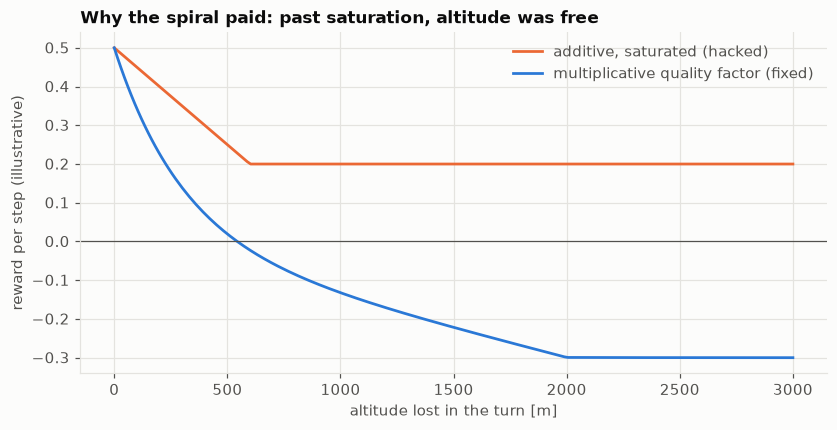

In [9]:
dh = np.linspace(0, 3000, 200)
rate_ratio_spiral = 1.0  # the turn-rate term is capped at the optimal rate
additive = 0.5 * rate_ratio_spiral - 0.3 * np.minimum(dh / 600, 1.0)  # saturating penalty
multiplicative = 0.5 * rate_ratio_spiral * np.exp(-dh / 300) - 0.3 * np.minimum(dh / 2000, 1.0)
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
ax.plot(dh, additive, color=SERIES[1], label="additive, saturated (hacked)")
ax.plot(dh, multiplicative, color=SERIES[0], label="multiplicative quality factor (fixed)")
ax.axhline(0, color=INK_2, linewidth=0.8)
ax.set_xlabel("altitude lost in the turn [m]"), ax.set_ylabel("reward per step (illustrative)")
ax.set_title("Why the spiral paid: past saturation, altitude was free")
ax.legend(loc="upper right")
plt.show()

*(Illustrative weights; the real reward has more terms, see `envs/tasks/turn.py`.)*

## 5. Imitation learning: when exploration is not enough

A loop takes ~20 s of coherent inputs before any "figure completed" reward arrives; random
exploration essentially never gets there. Pure PPO on aerobatics only discovered the aileron roll
(35 % success). The fix: start from **demonstrations** by the scripted pilot, then fine-tune with
RL.

* **Behavior cloning** fits the policy mean to the reference actions by regression:
  $\min_\theta \ \mathbb E\big[\lVert \mu_\theta(o) - a_{ref}(o) \rVert^2\big]$.
* **DART** noise: during data collection the *executed* action is perturbed, but the *recorded*
  label is the clean reference action. The demonstrations then include small mistakes and how to
  correct them ; without this, a clone drifts off the ideal path and has never seen how to come
  back.
* **Critic warm-up**: after cloning, the policy is good but the critic knows nothing, so the first
  PPO updates are driven by noise and wreck the clone (82 → −28 return in 50k steps, observed).
  The actor is therefore frozen for the first 5 PPO iterations while the critic learns.

Live demo: clone the scripted aerobatics pilot from 60 demonstrations (about a minute).

In [10]:
aero_cfg = EnvConfig(task="aerobatics", model="3dof", discount=0.995)
demos = collect_demonstrations(aero_cfg, episodes=60, noise=0.1)
print(f"{len(demos):,} (observation, action) pairs from 60 noisy demonstrations")

aero_env = JetEnv(aero_cfg)
student = PPO(
    "MlpPolicy",
    aero_env,
    device="cpu",
    seed=0,
    policy_kwargs={"net_arch": [256, 256], "log_std_init": -2.0},
)
untrained = evaluate(aero_env, AgentPolicy(student), episodes=12, seed=EVAL_SEED)
losses = behavior_cloning(student, demos, epochs=30)
print(f"behavior cloning: mean squared error {losses[0]:.4f} -> {losses[-1]:.5f}")

print(f"\n  untrained network : {fmt(untrained)}")
print(f"  cloned network    : {fmt(evaluate(aero_env, AgentPolicy(student), 12, EVAL_SEED))}")
print(f"  scripted pilot    : {fmt(evaluate(aero_env, reference_policy(aero_env), 12, EVAL_SEED))}")

8,295 (observation, action) pairs from 60 noisy demonstrations
behavior cloning: mean squared error 0.0883 -> 0.00051

  untrained network : return  -23.6 ±  5.7 | success   0% | crash   0%
  cloned network    : return   57.9 ±  1.5 | success 100% | crash   0%
  scripted pilot    : return   58.2 ±  1.3 | success 100% | crash   0%


A neural network that has never been rewarded now flies aerobatic figures. Here are the four
figures flown by the **clone** (side view, in the vertical plane of the initial heading):

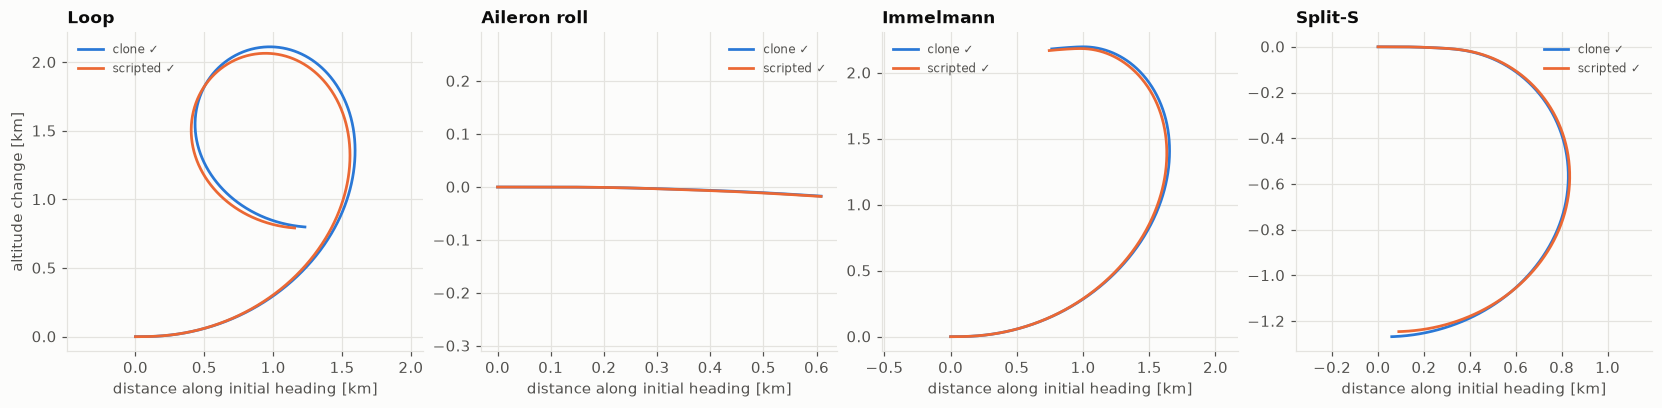

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), layout="constrained")
for ax, maneuver in zip(axes, ("loop", "roll", "immelmann", "split_s"), strict=True):
    cfg_m = replace(aero_cfg, task_kwargs={"maneuvers": [maneuver]})
    for (name, policy), color in zip(
        (("clone", AgentPolicy(student)), ("scripted", None)), SERIES, strict=False
    ):
        rec, info = fly(cfg_m, policy, EVAL_SEED)
        ins = rec.instruments
        chi0 = ins["course"][0]
        along = (ins["north"] - ins["north"][0]) * math.cos(chi0) + (
            ins["east"] - ins["east"][0]
        ) * math.sin(chi0)
        ok = "✓" if info["is_success"] else "✗"
        ax.plot(
            along / 1000,
            (ins["altitude"] - ins["altitude"][0]) / 1000,
            color=color,
            label=f"{name} {ok}",
        )
    ax.set_title(
        {"loop": "Loop", "roll": "Aileron roll", "immelmann": "Immelmann", "split_s": "Split-S"}[
            maneuver
        ]
    )
    ax.set_xlabel("distance along initial heading [km]")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="best", fontsize=8)
axes[0].set_ylabel("altitude change [km]")
plt.show()

In the full run (`8_5_aerobatics_imitation.yaml`: 80 demonstrations, then 3 M steps of cautious
PPO) the agent keeps 100 % success and slightly improves on its teacher (58.2 vs 57.9).

## 6. From 3-DOF to 6-DOF: transfer

Observations always start with the same own-ship features, and the hierarchical action space is
identical for both models, so a 3-DOF policy can be copied into a 6-DOF agent
(`training/transfer.py`): all weights of matching shape are copied; a first layer that only gained new
inputs gets its known columns copied and zeros elsewhere; the exploration noise is *not* copied
(the source policy had become too timid for the new task).

One lesson: the 3-DOF agent for 8.1 alternated its roll command at every step, harmless in 3-DOF
(instant roll response) but a 5 Hz roll oscillation on the 6-DOF, where the transferred agent
first reached only 20 % success. With the smoother gravity-based attitude observation and 1 M
steps of fine-tuning it reached 100 %.

In [12]:
if HAVE_RUNS:
    print(f"{'task':<24}{'3-DOF agent / autopilot':>26}{'6-DOF agent / autopilot':>27}")
    for name, title in CURRICULUM[:4]:
        r3, r6 = load_run(name), load_run(f"{name}_6dof")
        if r3 is None or r6 is None:
            continue
        cells = []
        for s, _, _ in (r3, r6):
            best = s["seeds"][0]["best"]
            cells.append(
                f"{best['mean_return']:6.1f} / {s['baseline']['mean_return']:5.1f}"
                f" ({best['success_rate']:.0%})"
            )
        print(f"{title:<24}{cells[0]:>26}{cells[1]:>27}")

task                       3-DOF agent / autopilot    6-DOF agent / autopilot
8.1 stabilize                  20.8 /  17.8 (100%)        20.0 /  17.3 (100%)
8.2 heading/altitude           126.8 /  89.0 (90%)        123.7 /  91.3 (90%)
8.3 sustained turn            290.9 / 274.2 (100%)       266.5 / 165.6 (100%)
8.4 waypoints                  48.6 /  39.2 (100%)        46.0 /  39.1 (100%)


## 7. Step 8.6: direct control of the surfaces

The final challenge removes the safety net: the agent commands throttle, elevator, ailerons and
rudder directly, at 50 Hz, with no fly-by-wire limiters or yaw damper. Settings that made it work:

* **50 Hz decisions** : the reference "autopilot + FBW" does not even fly at 10 Hz;
* rewards scaled per unit of time ($\times\,\Delta t / 0.1$ s) so returns stay comparable with
  the hierarchical agents; extra penalties near the structural limits and for sideslip;
* start by **imitating "autopilot + fly-by-wire"** (its surface commands), then critic warm-up,
  then cautious PPO: tiny exploration noise (σ ≈ 0.7° of elevator), $\gamma = 0.998$ and
  $\lambda = 0.99$ so the horizon still spans ~10 s at 50 Hz.

Results (1 seed, 5 M steps each, best evaluated model):

In [13]:
LOW_LEVEL = [
    ("8_6_level", "8.1 stabilize", 20.0),
    ("8_6_heading_altitude", "8.2 heading/alt.", 123.7),
    ("8_6_sustained_turn", "8.3 sustained turn", 266.5),
    ("8_6_waypoints", "8.4 waypoints", 46.0),
    ("8_6_aerobatics", "8.5 aerobatics", 55.3),
]
if HAVE_RUNS:
    print(
        f"{'task':<20}{'low-level agent':>18}{'reference':>12}"
        f"{'hierarchical 6-DOF':>20}{'ratio':>8}"
    )
    for name, title, hier in LOW_LEVEL:
        run = load_run(name)
        if run is None:
            continue
        s = run[0]
        best = s["seeds"][0]["best"]
        print(
            f"{title:<20}{best['mean_return']:>9.1f} ({best['success_rate']:4.0%})"
            f"{s['baseline']['mean_return']:>12.1f}{hier:>20.1f}{best['mean_return'] / hier:>8.0%}"
        )

task                   low-level agent   reference  hierarchical 6-DOF   ratio
8.1 stabilize            16.7 (100%)        16.9                20.0     83%
8.2 heading/alt.         89.5 (100%)        91.0               123.7     72%
8.3 sustained turn      225.1 (100%)       165.6               266.5     84%
8.4 waypoints            38.3 ( 90%)        38.9                46.0     83%
8.5 aerobatics           57.4 (100%)        57.4                55.3    104%


No envelope violation at all (the overload penalty stayed at zero). The low-level agents reach
90–100 % success and 72–100 % of the hierarchical agent's return; on the sustained turn PPO
clearly improves beyond the imitated reference (+36 %).

But not everything went well, and it is worth showing. On 8.2, PPO **degraded** the imitated
policy after 1–2 M steps, while the usual health indicators (KL divergence, explained variance,
exploration σ) showed nothing wrong. Keeping the best evaluated model saved the result; the
roadmap lists regularization towards the imitated policy and early stopping as next steps.

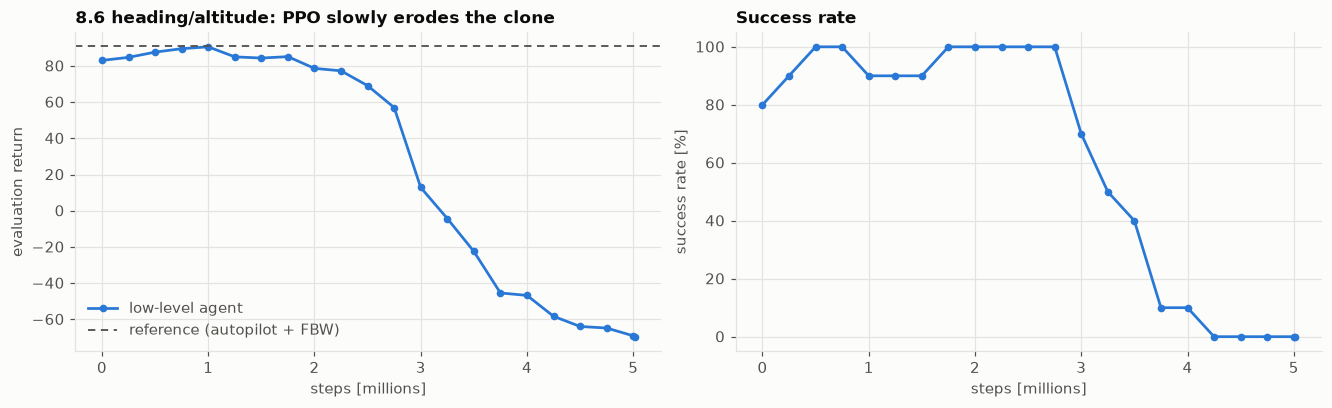

In [14]:
if HAVE_RUNS and (run := load_run("8_6_heading_altitude")) is not None:
    summary, hist, _ = run
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), layout="constrained", sharex=True)
    axes[0].plot(
        hist["timesteps"] / 1e6,
        hist["mean_return"],
        "o-",
        color=SERIES[0],
        markersize=4,
        label="low-level agent",
    )
    axes[0].axhline(
        summary["baseline"]["mean_return"],
        color=INK_2,
        linewidth=1.2,
        linestyle=(0, (4, 3)),
        label="reference (autopilot + FBW)",
    )
    axes[0].set_ylabel("evaluation return"), axes[0].legend(loc="lower left")
    axes[0].set_title("8.6 heading/altitude: PPO slowly erodes the clone")
    axes[1].plot(
        hist["timesteps"] / 1e6, 100 * hist["success_rate"], "o-", color=SERIES[0], markersize=4
    )
    axes[1].set_ylabel("success rate [%]"), axes[1].set_title("Success rate")
    for ax in axes:
        ax.set_xlabel("steps [millions]")
    plt.show()

## 8. Summary

Each bar is an agent's return relative to *its own* reference on the same evaluation episodes
(100 % = matches the autopilot / scripted pilot; the 6-DOF reference differs from the 3-DOF one).
Numbers from `project_roadmap.md`.

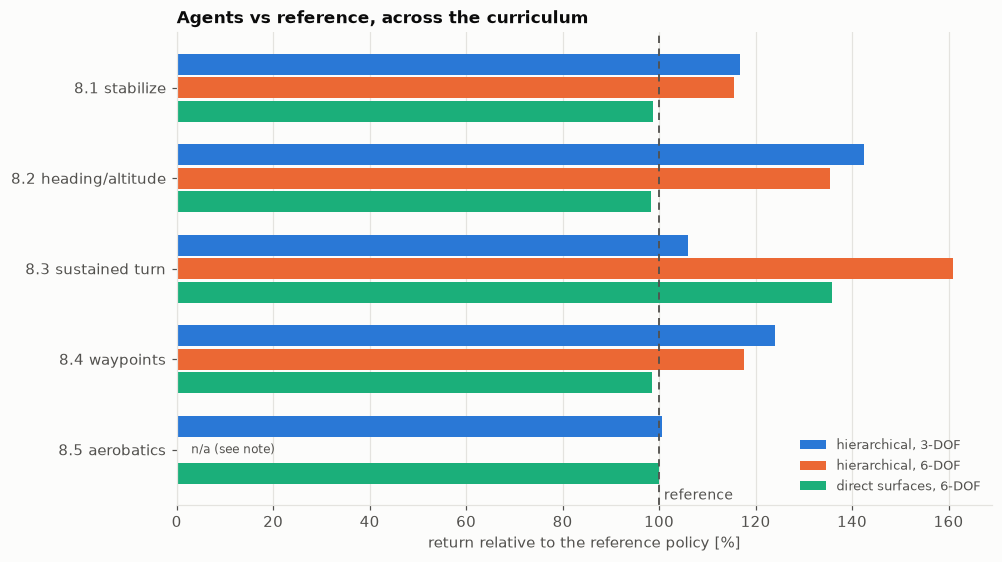

In [15]:
tasks = [
    "8.1 stabilize",
    "8.2 heading/altitude",
    "8.3 sustained turn",
    "8.4 waypoints",
    "8.5 aerobatics",
]
groups = {  # (agent return, reference return); None = no valid result
    "hierarchical, 3-DOF": [
        (20.8, 17.8),
        (126.8, 89.0),
        (290.9, 274.2),
        (48.6, 39.2),
        (58.2, 57.9),
    ],
    "hierarchical, 6-DOF": [(20.0, 17.3), (123.7, 91.3), (266.5, 165.6), (46.0, 39.1), None],
    "direct surfaces, 6-DOF": [
        (16.7, 16.9),
        (89.5, 91.0),
        (225.1, 165.6),
        (38.3, 38.9),
        (57.4, 57.4),
    ],
}
y = np.arange(len(tasks))[::-1]
h = 0.26
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for k, ((label, values), color) in enumerate(zip(groups.items(), SERIES, strict=True)):
    ratios = [np.nan if v is None else 100 * v[0] / v[1] for v in values]
    ax.barh(y + (1 - k) * h, ratios, height=h - 0.03, color=color, label=label)
ax.axvline(100, color=INK_2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(101, y[-1] - 0.55, "reference", color=INK_2, fontsize=9)
ax.text(3, y[-1] + (1 - 1) * h, "n/a (see note)", va="center", color=INK_2, fontsize=8)
ax.set_yticks(y, tasks)
ax.set_xlabel("return relative to the reference policy [%]")
ax.set_title("Agents vs reference, across the curriculum")
ax.set_axisbelow(True)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=8.5)
plt.show()

*Note: the 6-DOF hierarchical aerobatics agent (55.3, 100 %) was trained before the 8.5 reward
hack was fixed and has not been retrained with the corrected task, so it is not counted.*

## What this project demonstrates

* **Physics first**: a validated 3-DOF and 6-DOF F-16 (NASA data, trim, modes, conservation laws)
  so that agents learn to fly, not to exploit bugs.
* **Control engineering**: fly-by-wire with gain scheduling and envelope protection, cascaded
  autopilot, LQR ; both a benchmark and the inner loop of hierarchical RL.
* **RL engineering**: a clean Gymnasium environment, careful action/observation/reward design,
  curriculum and transfer, imitation learning with DART and critic warm-up, reproducible YAML
  experiments with TensorBoard logging and automatic comparison to the baseline.
* **Scientific honesty**: trajectories inspected systematically, five reward hacks found and
  fixed, failures and limits documented (single seed so far; PPO degrading imitated policies).
